#### **Importing Required Python libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from scipy import stats
from sklearn.ensemble import RandomForestClassifier

### **Load dataset**

In [ ]:
dataset=pd.read_csv("/content/dataset 2.csv")

### **Summarize data**

In [ ]:
dataset

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [ ]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))

Shape of the dataset is (4424, 35). This dataset contains 4424 rows and 35 columns.


### **Feature Names and its Datatypes**

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

### **Data Spliting**
#### Select and separately store Numerical and Categorical features in different variables.

In [ ]:
##Selecting numerical features
numerical_data = dataset.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 34 numerical features: 

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [ ]:
#Selecting categoricalfeatures
categorical_data=dataset.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 1 categorical features: 

['Target']


###Removing Null values / Handling Missing data

In [ ]:
dataset.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


#

# For numaric type data


In [ ]:
#For numaric type data
print("Shape of dataframe before dropping:", dataset.shape)
for col in dataset.columns:
    if col in numerical_features and dataset[col].isnull().sum() >= 450:
      dataset = dataset.dropna(axis=0, subset=[col])  # Drop rows where that column is null
    elif col in numerical_features:
        dataset[col] = dataset[col].fillna(dataset[col].mean())
print("Shape of dataframe after dropping:", dataset.shape)

Shape of dataframe before dropping: (4424, 35)
Shape of dataframe after dropping: (4424, 35)


In [ ]:
dataset.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


In [ ]:
#For catagorical type data
print("Shape of dataframe before dropping:", dataset.shape)
dataset = dataset.dropna(axis=0, subset=[col])  # Drop rows where that column is null
print("Shape of dataframe before dropping:", dataset.shape)

Shape of dataframe before dropping: (4424, 35)
Shape of dataframe before dropping: (4424, 35)


In [ ]:
dataset.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [ ]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))

Shape of the dataset is (4424, 35). This dataset contains 4424 rows and 35 columns.


### **Descriptive Analysis**
#### In descriptive Analysis we analysis each variable separately to get inference about the feature.
### **Summary satistics of Numerical Features**

In [ ]:
# Transposed stats for numerical features

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nacionality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Target,4424,3,Graduate,2209


### **Variance of each numerical features**

In [ ]:
numerical_data.var()

,0
Marital status,0.366929
Application mode,28.079017
Application order,1.726052
Course,18.764422
Daytime/evening attendance,0.097280
Previous qualification,15.710973
Nacionality,3.057068
Mother's qualification,81.473208
Father's qualification,121.987596
Mother's occupation,15.982626


In [ ]:
numerical_data.skew()

,0
Marital status,4.399764
Application mode,0.121696
Application order,1.881050
Course,-0.189557
Daytime/evening attendance,-2.507238
Previous qualification,2.405934
Nacionality,7.282730
Mother's qualification,-0.097197
Father's qualification,-0.291740
Mother's occupation,2.231227


### **Histograms and Box Plot**
#### To find the distributions and outlier in the each feature

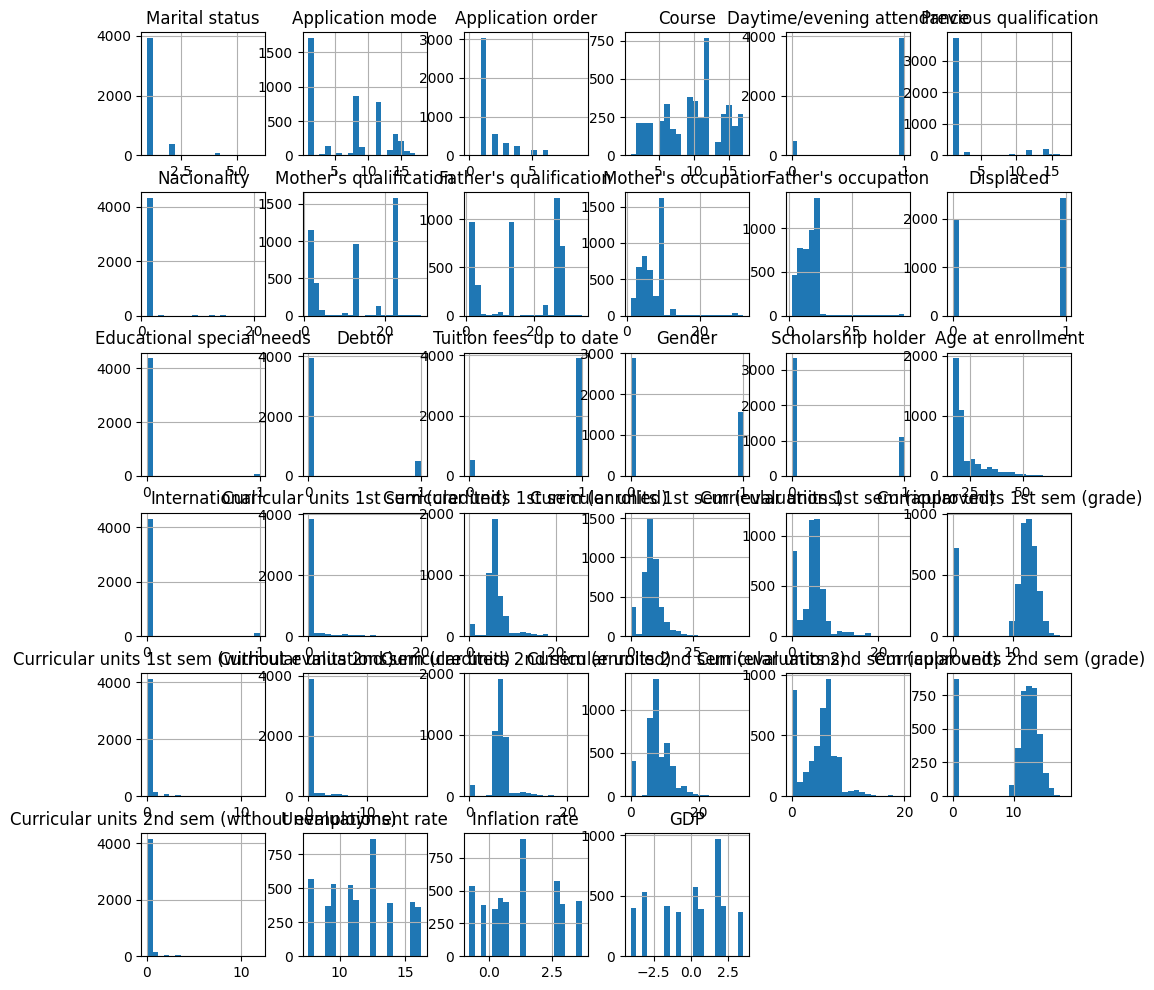

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

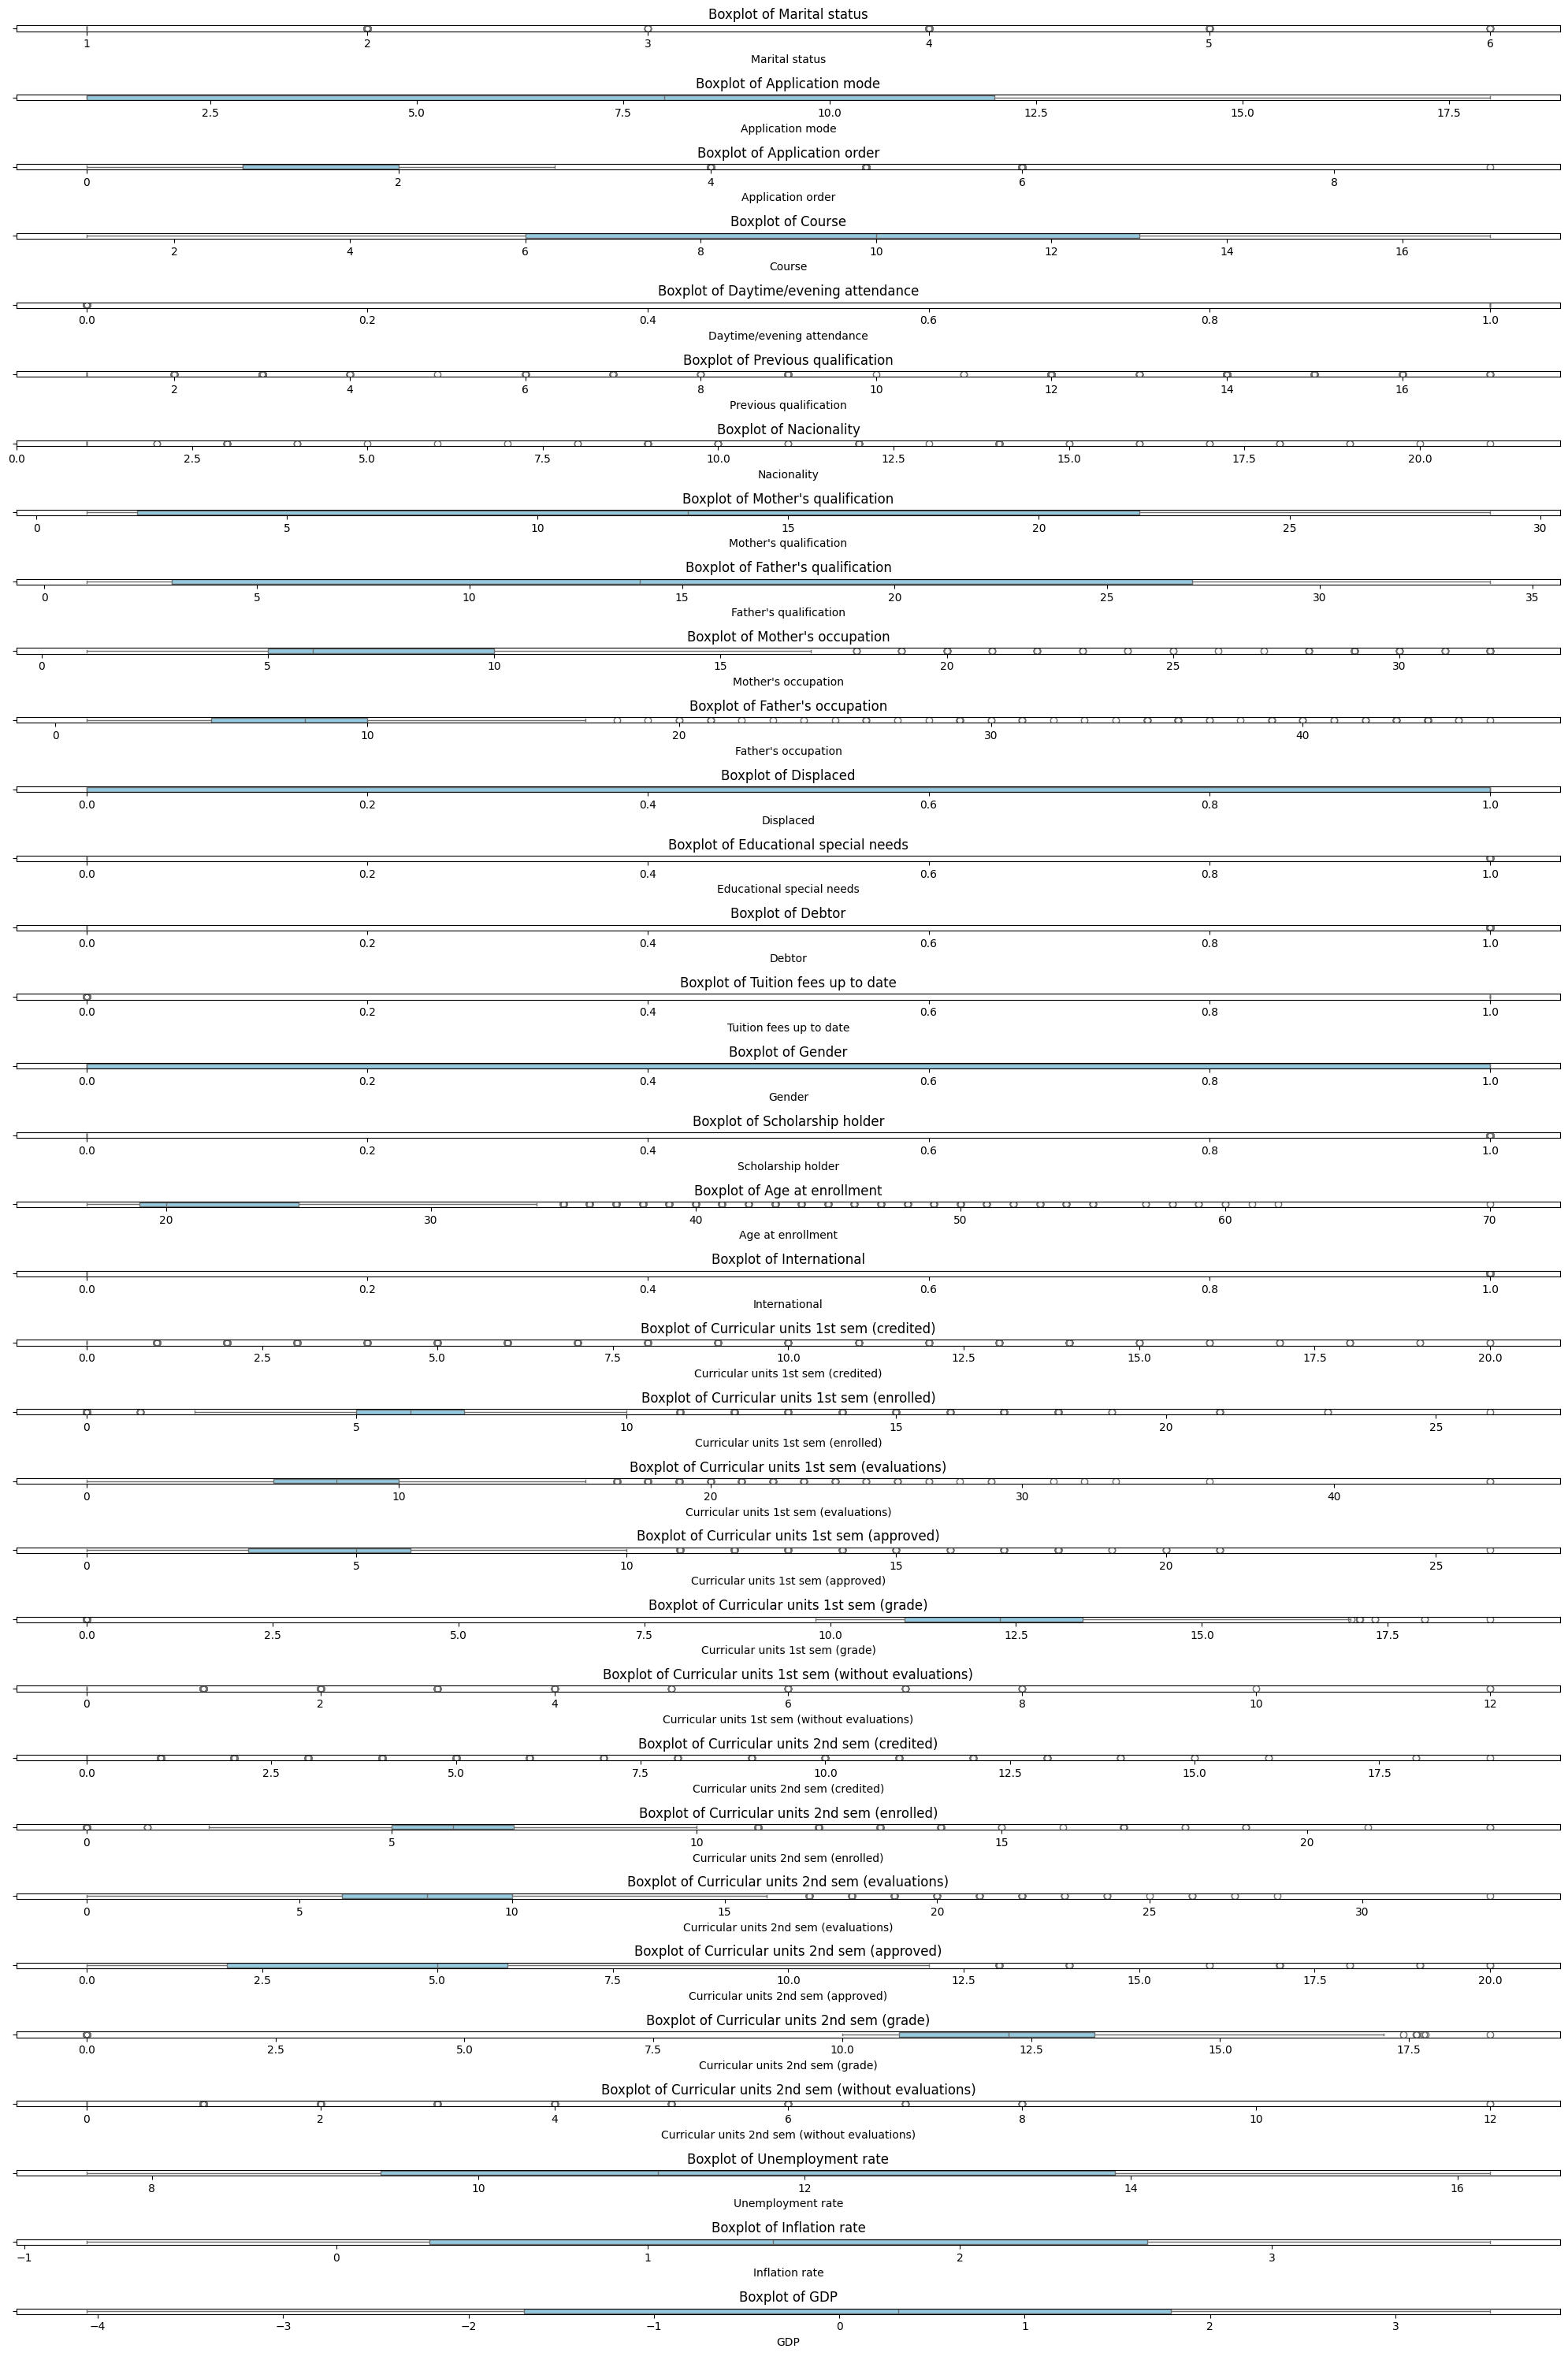

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


### **Number Unique values in each feature**

In [ ]:
numerical_data.nunique()

,0
Marital status,6
Application mode,18
Application order,8
Course,17
Daytime/evening attendance,2
Previous qualification,17
Nacionality,21
Mother's qualification,29
Father's qualification,34
Mother's occupation,32


### **Categorical Features**


#### **No of unique values in each categorical feature**

In [ ]:
# unique values counts
unique_counts=categorical_data.nunique()
print(unique_counts)

Target    3
dtype: int64


### **Barplot of unique value counts in every categorical features**

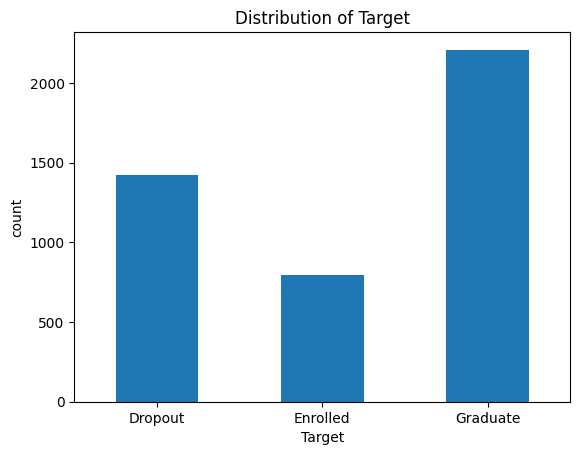

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

### **Correlation Analysis**
### **Correlation matrix of whole dataset**

In [ ]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
Marital status,1.000000,0.224855,-0.125854,0.018925,-0.274939,0.120925,-0.020722,0.185522,0.128326,0.069734,...,0.034711,0.062831,0.039026,0.022784,-0.043739,-0.071506,0.020426,-0.020338,0.008761,-0.027003
Application mode,0.224855,1.000000,-0.246497,-0.085116,-0.268616,0.433028,-0.001360,0.092867,0.072798,0.033489,...,0.040255,0.228973,0.127461,0.164992,-0.065203,-0.104424,0.042009,0.091567,-0.019613,-0.014563
Application order,-0.125854,-0.246497,1.000000,0.118928,0.158657,-0.199029,-0.029385,-0.061719,-0.049936,-0.046591,...,-0.031699,-0.125815,0.028878,-0.055089,0.071793,0.055517,-0.015757,-0.098419,-0.011133,0.030201
Course,0.018925,-0.085116,0.118928,1.000000,-0.070232,-0.158382,-0.004761,0.058909,0.045659,0.029672,...,-0.060483,-0.120390,0.185879,0.049236,0.120000,0.178997,-0.013984,-0.050116,0.028775,-0.012518
Daytime/evening attendance,-0.274939,-0.268616,0.158657,-0.070232,1.000000,-0.103022,0.024433,-0.195346,-0.137769,-0.037986,...,0.045630,-0.111953,0.000371,0.014610,0.034022,0.050493,-0.004229,0.061974,-0.024043,0.022929
Previous qualification,0.120925,0.433028,-0.199029,-0.158382,-0.103022,1.000000,-0.038997,0.018868,0.013152,0.006190,...,0.018276,0.138463,0.056450,0.101501,-0.037265,-0.038765,0.024186,0.096914,-0.056388,0.053968
Nacionality,-0.020722,-0.001360,-0.029385,-0.004761,0.024433,-0.038997,1.000000,-0.043847,-0.088892,0.044123,...,0.026203,-0.000747,-0.020103,-0.018023,-0.014142,-0.005409,-0.012052,-0.006013,-0.012331,0.044563
Mother's qualification,0.185522,0.092867,-0.061719,0.058909,-0.195346,0.018868,-0.043847,1.000000,0.524529,0.295178,...,0.003293,0.036986,0.033070,0.018874,-0.013161,-0.028472,0.020364,-0.106107,0.056653,-0.079664
Father's qualification,0.128326,0.072798,-0.049936,0.045659,-0.137769,0.013152,-0.088892,0.524529,1.000000,0.207067,...,-0.017785,0.041695,0.023635,0.009471,0.006052,-0.006508,-0.008493,-0.075417,0.056661,-0.070200
Mother's occupation,0.069734,0.033489,-0.046591,0.029672,-0.037986,0.006190,0.044123,0.295178,0.207067,1.000000,...,-0.012569,-0.002057,0.009287,0.011546,0.022309,0.035230,-0.004903,-0.011772,0.015014,0.091880


### **Correlation Heatmap plot of whole dataset**

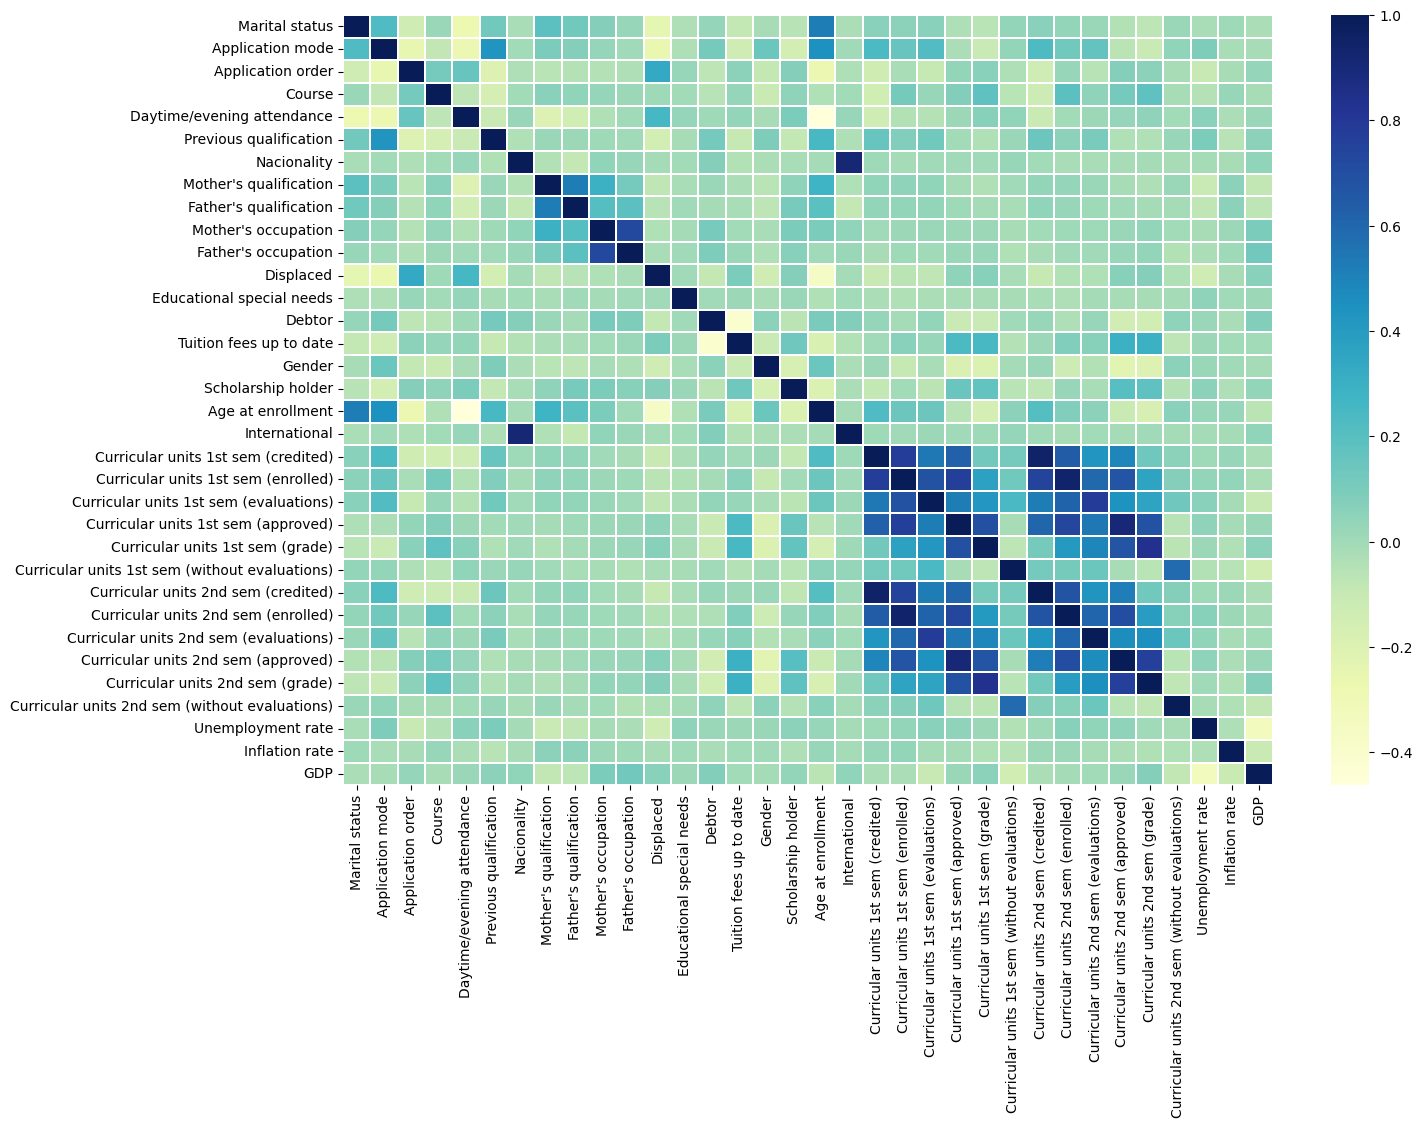

In [ ]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, cmap='YlGnBu', linewidths=0.3)
plt.show()

### **Generating correlation plot between features and target variable using different method**

#### **Correlation plot between numerical features and target**

In [ ]:
dataset['Target'] = dataset['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

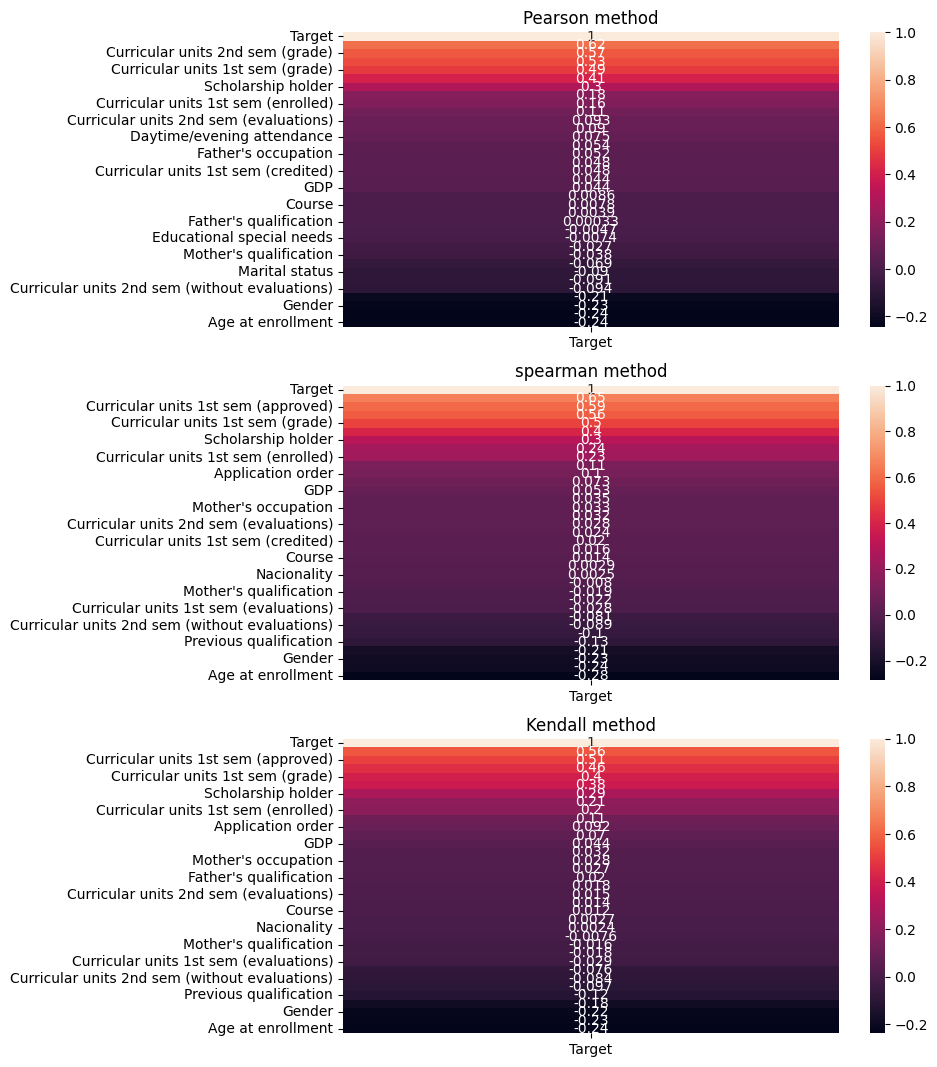

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(8, 13))
## Correlation coefficient using different methods
corr1 = dataset.corr('pearson')[['Target']].sort_values(by='Target', ascending=False)
corr2 = dataset.corr('spearman')[['Target']].sort_values(by='Target', ascending=False)
corr3 = dataset.corr('kendall')[['Target']].sort_values(by='Target', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

### **Check imbalance in the data**
#### We have classification problem so we need to check the balance of the given data.

In [ ]:
#check Imbalance in data

#group instances based on the classes in OUTCOME variable
class_counts=dataset.groupby("Target").size()

columns=['outcome','count','percentage']
outcome=[0,1, 2]
count=list()
percentage=list()
total = len(dataset)
#Calculate the percentage of each value of the OUTCOME variable from total
for val in range(3):
    count.append(class_counts[val])
    percent=(class_counts[val]/total)*100
    percentage.append(percent)

# Convert the calulated values into a dataframe
imbalance_df=pd.DataFrame(list(zip(outcome,count,percentage)),columns=columns)
imbalance_df

,outcome,count,percentage
0,0,1421,32.120253
1,1,794,17.947559
2,2,2209,49.932188


### **Barplot of Outcome vs Percentage**

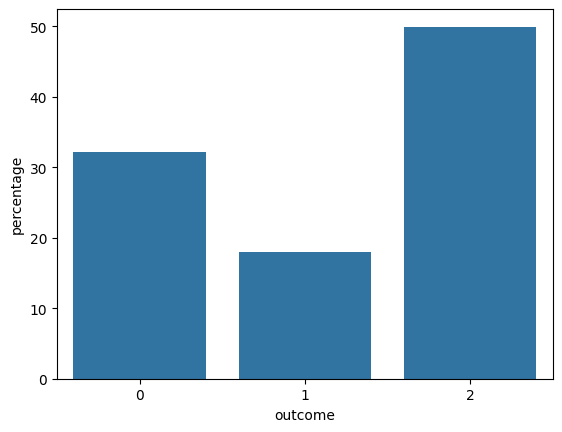

In [ ]:
sns.barplot(data=imbalance_df,x=imbalance_df['outcome'],y=imbalance_df['percentage'])
plt.show()

### **Observation**
Around 55% of students are Graduates (2)

Around 29% are Dropouts (0)

Only 16% are still Enrolled (1)

The dataset shows a clear class imbalance, with Graduates being the majority class.

### **Data visualization**
#### Some other visualizations of features to get more insights

### **Density plots of numerical features**

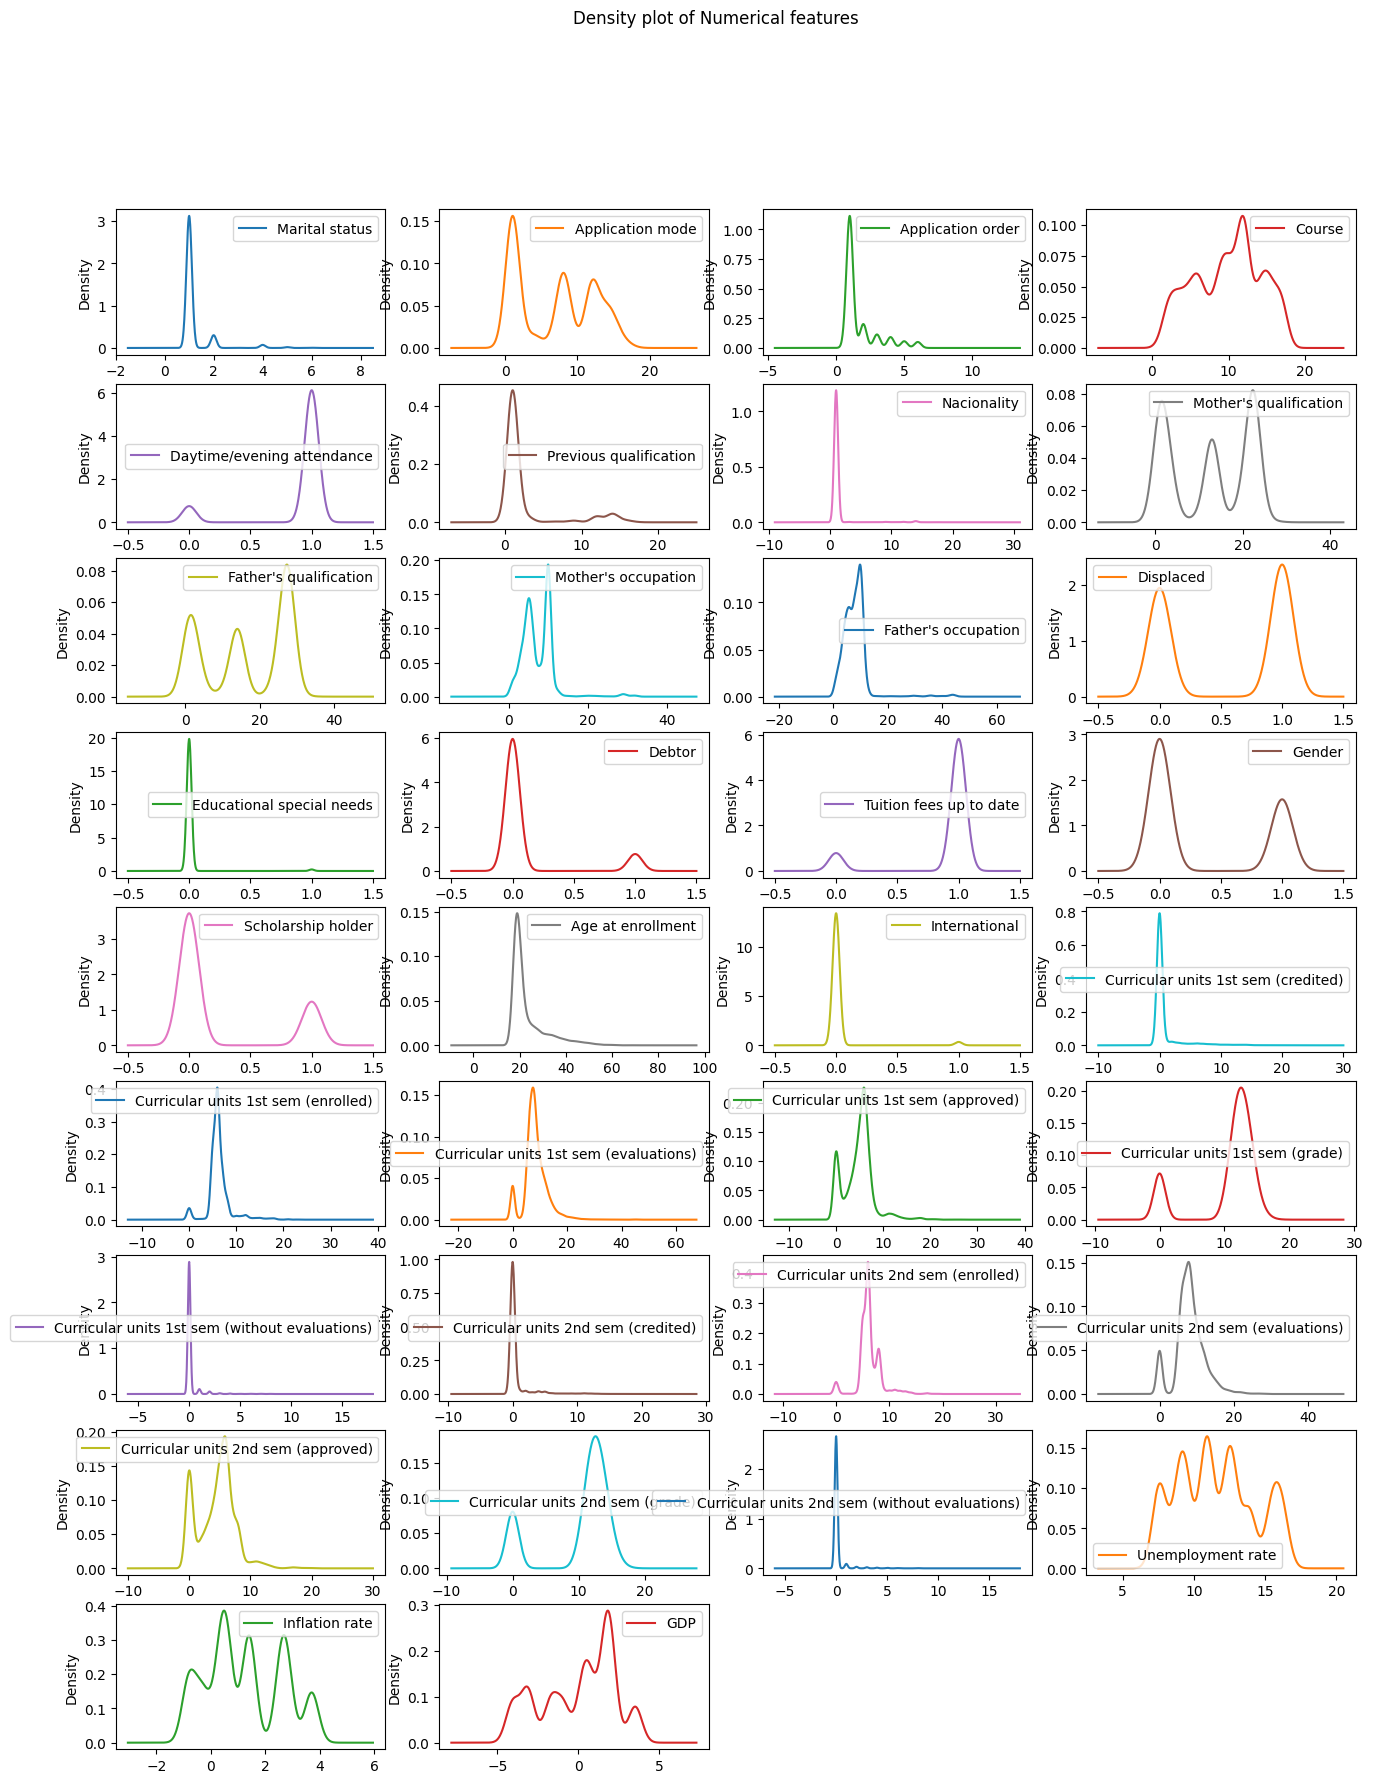

In [ ]:
numerical_data.plot(kind='density',figsize=(16,20),subplots=True,layout=(9,4),title="Density plot of Numerical features",sharex=False)
plt.show()

## Define features and target

In [ ]:

X = dataset.drop(['Target'], axis=1)
y = dataset['Target']


###Train-Test Split & Feature Scaling with StandardScaler

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


##Train Multiple Models

In [ ]:
svm = SVC(kernel='rbf', probability=True, random_state=10)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division=0))

SVC Accuracy: 0.7680722891566265
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       441
           1       0.59      0.32      0.42       245
           2       0.76      0.94      0.84       642

    accuracy                           0.77      1328
   macro avg       0.73      0.68      0.69      1328
weighted avg       0.76      0.77      0.75      1328



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNeighborsClassifier Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, zero_division=0))

KNeighborsClassifier Accuracy: 0.7025602409638554
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       441
           1       0.40      0.25      0.31       245
           2       0.73      0.87      0.80       642

    accuracy                           0.70      1328
   macro avg       0.63      0.61      0.61      1328
weighted avg       0.68      0.70      0.69      1328



In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Gaussian Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, zero_division=0))

Gaussian Naive Bayes Accuracy: 0.7070783132530121
              precision    recall  f1-score   support

           0       0.79      0.71      0.75       441
           1       0.42      0.32      0.36       245
           2       0.74      0.85      0.79       642

    accuracy                           0.71      1328
   macro avg       0.65      0.63      0.63      1328
weighted avg       0.70      0.71      0.70      1328



In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state=10, max_iter=500) # Increased max_iter for convergence
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("MLP Classifier Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp, zero_division=0))

MLP Classifier Accuracy: 0.7424698795180723
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       441
           1       0.49      0.42      0.45       245
           2       0.81      0.85      0.83       642

    accuracy                           0.74      1328
   macro avg       0.69      0.68      0.68      1328
weighted avg       0.73      0.74      0.74      1328



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


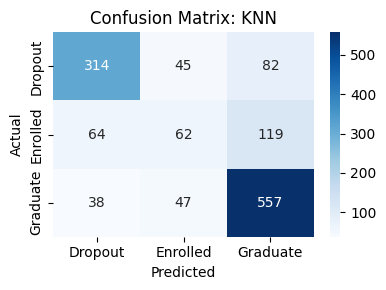

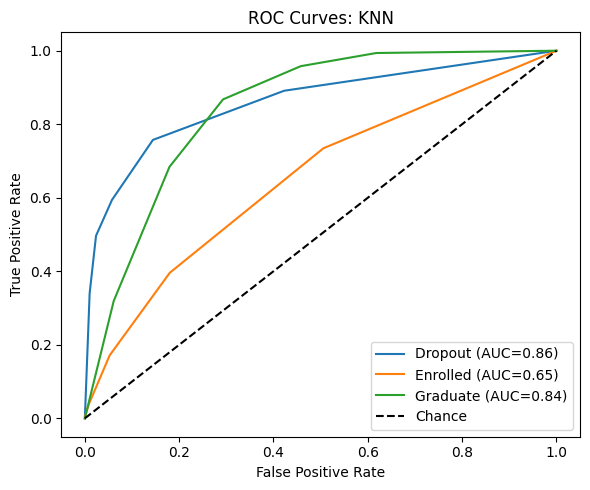

--- KNN Classification Report ---
              precision    recall  f1-score   support

     Dropout       0.75      0.71      0.73       441
    Enrolled       0.40      0.25      0.31       245
    Graduate       0.73      0.87      0.80       642

    accuracy                           0.70      1328
   macro avg       0.63      0.61      0.61      1328
weighted avg       0.68      0.70      0.69      1328



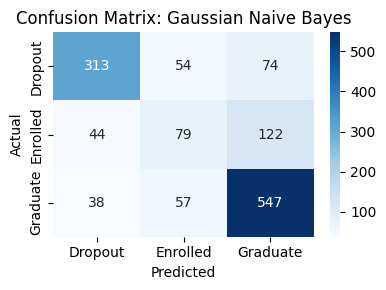

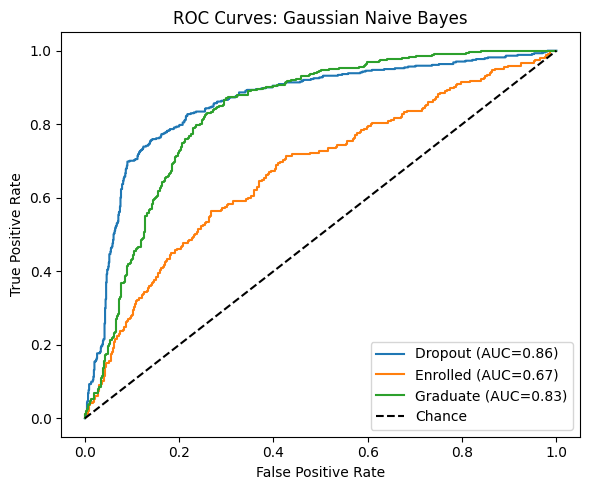

--- Gaussian Naive Bayes Classification Report ---
              precision    recall  f1-score   support

     Dropout       0.79      0.71      0.75       441
    Enrolled       0.42      0.32      0.36       245
    Graduate       0.74      0.85      0.79       642

    accuracy                           0.71      1328
   macro avg       0.65      0.63      0.63      1328
weighted avg       0.70      0.71      0.70      1328



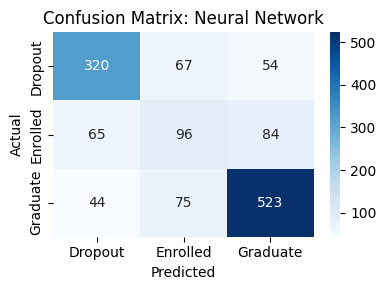

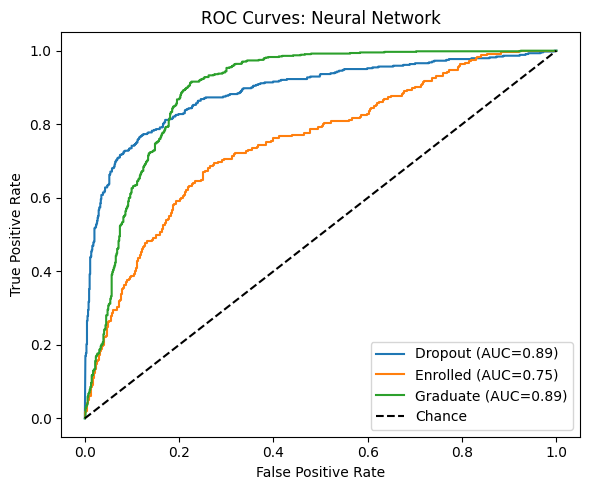

--- Neural Network Classification Report ---
              precision    recall  f1-score   support

     Dropout       0.75      0.73      0.74       441
    Enrolled       0.40      0.39      0.40       245
    Graduate       0.79      0.81      0.80       642

    accuracy                           0.71      1328
   macro avg       0.65      0.64      0.65      1328
weighted avg       0.70      0.71      0.71      1328



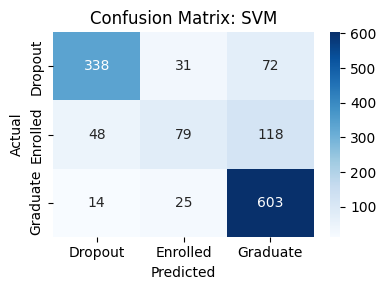

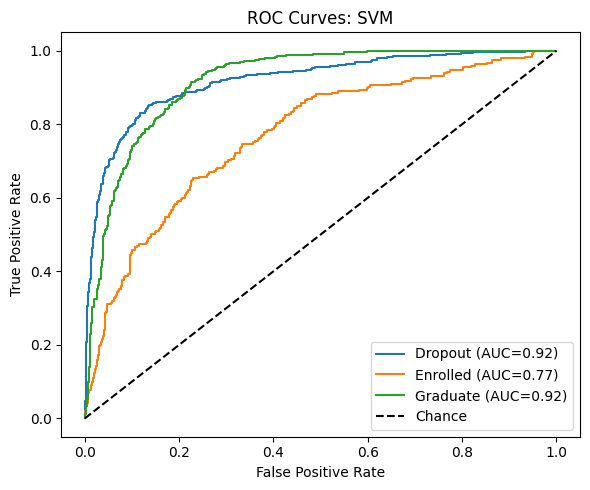

--- SVM Classification Report ---
              precision    recall  f1-score   support

     Dropout       0.84      0.77      0.80       441
    Enrolled       0.59      0.32      0.42       245
    Graduate       0.76      0.94      0.84       642

    accuracy                           0.77      1328
   macro avg       0.73      0.68      0.69      1328
weighted avg       0.76      0.77      0.75      1328



In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier


classifiers = {
    "KNN": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# STORAGE
clf_results = {}

for name, model in classifiers.items():
    # Train & Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted')
    clf_results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec}

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['Dropout','Enrolled','Graduate'],
                yticklabels=['Dropout','Enrolled','Graduate'],
                cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC & AUC (One‑vs‑Rest)
    y_bin_test = label_binarize(y_test, classes=[0,1,2])
    ovr = OneVsRestClassifier(model)
    # probability=True in SVC allows this predict_proba call to work
    y_score = ovr.fit(X_train, y_train).predict_proba(X_test)

    plt.figure(figsize=(6,5))
    for i, label in enumerate(['Dropout','Enrolled','Graduate']):
        fpr, tpr, _ = roc_curve(y_bin_test[:,i], y_score[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],'k--', label='Chance')
    plt.title(f'ROC Curves: {name}')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()



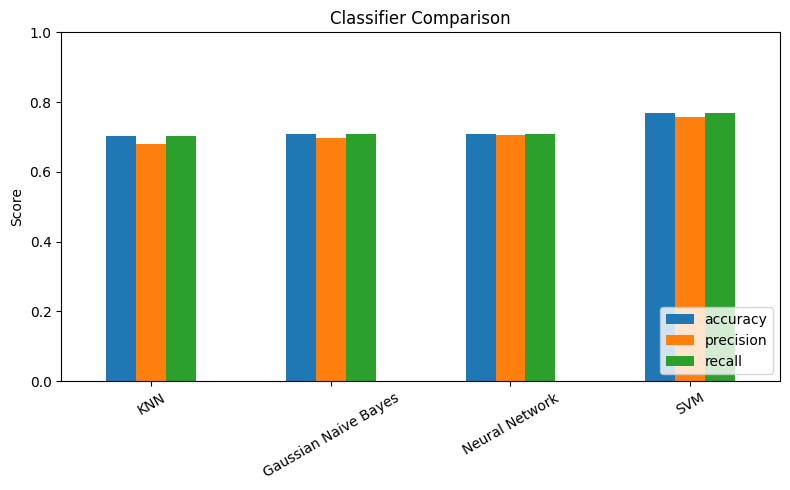

In [ ]:
# ── 3) SUMMARY BARS ────────────────────────────────────────────────────────────
df_clf = pd.DataFrame(clf_results).T
df_clf[['accuracy','precision','recall']].plot(
    kind='bar', figsize=(8,5), rot=0, title='Classifier Comparison'
)
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()